# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


I chose **OIL & GAS ENERGY SECTOR:**
XOM – Exxon Mobil

CVX – Chevron

SHEL – Shell

BP – BP:

In [4]:
tickers = ['XOM', 'CVX', 'SHEL', 'BP']


## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [6]:

!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


# Downloading 5 years of daily 'High' prices
df = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01"
)['High']

# Preview first few rows
df.head()


/tmp/ipython-input-2078956954.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  4 of 4 completed


Ticker,BP,CVX,SHEL,XOM
Date,,,,
2020-01-02,27.506342,93.070922,47.233504,53.752537
2020-01-03,28.184090,93.904991,47.691854,54.017437
2020-01-06,28.897885,93.101521,48.339849,54.009877
2020-01-07,28.465281,91.617049,47.755064,53.374118
2020-01-08,28.335500,91.127321,47.359939,53.200026


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [8]:
# Check for missing values
df.isnull().sum()

# Handle missing values using forward fill
df = df.ffill()

# Recheck for missing values
df.isnull().sum()

,0
Ticker,
BP,0
CVX,0
SHEL,0
XOM,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [10]:
#Calculate daily percentage returns
returns = df.pct_change()

# Drop rows with NaN created by pct_change()
returns = returns.dropna()

# Preview daily returns
returns.head()


Ticker,BP,CVX,SHEL,XOM
Date,,,,
2020-01-03,0.024640,0.008962,0.009704,0.004928
2020-01-06,0.025326,-0.008556,0.013587,-0.000140
2020-01-07,-0.014970,-0.015945,-0.012097,-0.011771
2020-01-08,-0.004559,-0.005345,-0.008274,-0.003262
2020-01-09,-0.008652,-0.009825,-0.003003,-0.005548


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




<Figure size 1200x600 with 0 Axes>

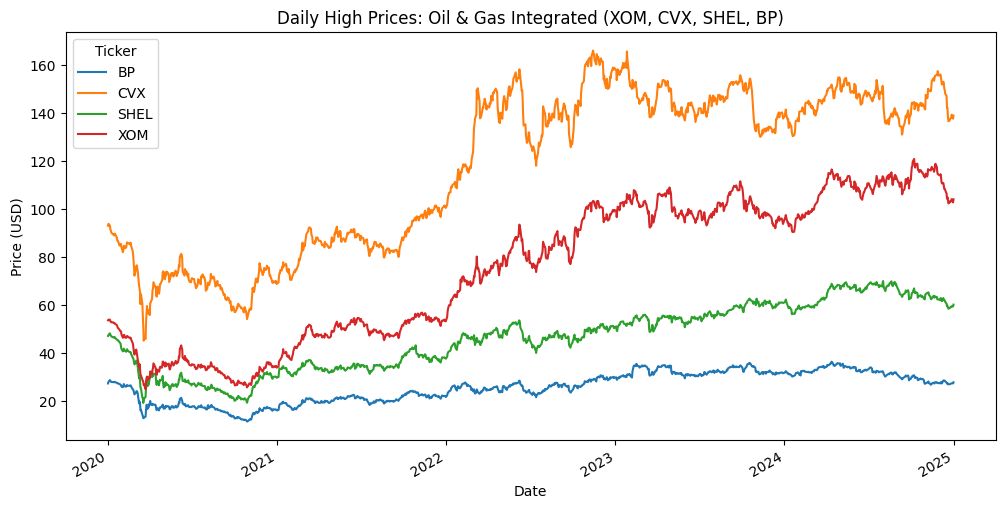

In [11]:
# Line chart of daily High prices
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6), title="Daily High Prices: Oil & Gas Integrated (XOM, CVX, SHEL, BP)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(title="Ticker")
plt.show()


In [14]:
volatility.sort_values(ascending=False)


,0
Ticker,
BP,0.022569
SHEL,0.021193
XOM,0.019356
CVX,0.018504


In [15]:
#Correlation matrix of daily returns
corr_matrix = returns.corr()
corr_matrix


Ticker,BP,CVX,SHEL,XOM
Ticker,,,,
BP,1.000000,0.748314,0.897928,0.758467
CVX,0.748314,1.000000,0.718909,0.838744
SHEL,0.897928,0.718909,1.000000,0.748046
XOM,0.758467,0.838744,0.748046,1.000000


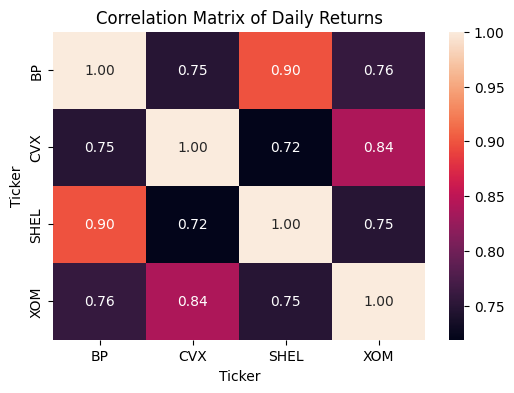

In [16]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Daily Returns")
plt.show()


## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

Business Memo – Oil & Gas Integrated Industry

**To:** Stakeholder
**From:** Yerke Nokenova
"Five-Year Stock Analysis of Major Oil & Gas Companies"

I analyzed the Oil & Gas Integrated industry using five years of stock data for Exxon Mobil (XOM), Chevron (CVX), Shell (SHEL) and BP (BP). The goal was to understand how all these companies performed over time and whether this industry is a good investment currently. I collected daily “High” prices and then calculated daily returns, volatility, and correlations to evaluate both trends and the risk levels.

From the price chart, all four stocks dropped sharply in early 2020, but each company recovered over time as energy demand returned. Overall, the trend across the five-year period is upward trend, especially for Chevron and Exxon, which show steady growth compared to BP and Shell. BP’s price stays the lowest, while Chevron consistently has the highest values. There are still noticeable ups and downs throughout the entire period, which reflects how sensitive this industry is to global oil prices i general.

The volatility numbers show that BP has the highest volatility, followed by SHEL, while CVX and XOM are the most stable. This matches what we see visually — BP and Shell have more dramatic price swings. The correlation matrix also shows very high correlations across all four companies (around 0.72–0.90), meaning that they move almost in the same directions. Because of these strong correlations, buying multiple companies in this industry does not provide much diversification to us







## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_14_LastnameFirstname.ipynb"